In [ ]:
!unzip '/content/drive/MyDrive/yolov8/hh.zip'

Archive:  /content/drive/MyDrive/yolov8/hh.zip
   creating: hh/
   creating: hh/img/
  inflating: hh/img/l4nr001.jpg      
  inflating: hh/img/l4nr002.jpg      
  inflating: hh/img/l4nr003.jpg      
  inflating: hh/img/l4nr004.jpg      
  inflating: hh/img/l4nr005.jpg      
  inflating: hh/img/l4nr006.jpg      
  inflating: hh/img/l4nr007.jpg      
  inflating: hh/img/l4nr008.jpg      
  inflating: hh/img/l4nr009.jpg      
  inflating: hh/img/l4nr010.jpg      
  inflating: hh/img/l4nr011.jpg      
  inflating: hh/img/l4nr012.jpg      
  inflating: hh/img/l4nr013.jpg      
  inflating: hh/img/l4nr014.jpg      
  inflating: hh/img/l4nr015.jpg      
  inflating: hh/img/l4nr016.jpg      
  inflating: hh/img/l4nr017.jpg      
  inflating: hh/img/l4nr018.jpg      
  inflating: hh/img/l4nr019.jpg      
  inflating: hh/img/l4nr020.jpg      
  inflating: hh/img/l4nr021.jpg      
  inflating: hh/img/l4nr022.jpg      
  inflating: hh/img/l4nr023.jpg      
  inflating: hh/img/l4nr024.jpg      
  i

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the path where you want to create the new directory
new_dataset_path ='/content/dataset'

# Create the directory if it doesn't exist
os.makedirs(new_dataset_path, exist_ok=True)


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import yaml
# Path to your original images and annotations
original_images_path = '/content/hh/img'
annotations_path = '/content/hh/label'

# Path to your new dataset directory
new_dataset_path = '/content/dataset'



In [ ]:
# New directory structure
train_images_path = os.path.join(new_dataset_path, 'images/train')
val_images_path = os.path.join(new_dataset_path, 'images/val')
test_images_path = os.path.join(new_dataset_path, 'images/test')
train_labels_path = os.path.join(new_dataset_path, 'labels/train')
val_labels_path = os.path.join(new_dataset_path, 'labels/val')
test_labels_path = os.path.join(new_dataset_path, 'labels/test')


In [ ]:
# Create directories if they don't exist
os.makedirs(train_images_path, exist_ok=True)
os.makedirs(val_images_path, exist_ok=True)
os.makedirs(test_images_path, exist_ok=True)
os.makedirs(train_labels_path, exist_ok=True)
os.makedirs(val_labels_path, exist_ok=True)
os.makedirs(test_labels_path, exist_ok=True)


In [ ]:
# Get list of all images and corresponding labels
image_files = sorted(os.listdir(original_images_path))
label_files = sorted(os.listdir(annotations_path))


In [ ]:
# Print lengths of image_files and label_files
print("Number of image files:", len(image_files))
print("Number of label files:", len(label_files))

# Print pairs of image and label filenames
for image, label in zip(image_files, label_files):
    print("Image:", image, "Label:", label)


Number of image files: 150
Number of label files: 150
Image: l4nr001.jpg Label: l4nr001.txt
Image: l4nr002.jpg Label: l4nr002.txt
Image: l4nr003.jpg Label: l4nr003.txt
Image: l4nr004.jpg Label: l4nr004.txt
Image: l4nr005.jpg Label: l4nr005.txt
Image: l4nr006.jpg Label: l4nr006.txt
Image: l4nr007.jpg Label: l4nr007.txt
Image: l4nr008.jpg Label: l4nr008.txt
Image: l4nr009.jpg Label: l4nr009.txt
Image: l4nr010.jpg Label: l4nr010.txt
Image: l4nr011.jpg Label: l4nr011.txt
Image: l4nr012.jpg Label: l4nr012.txt
Image: l4nr013.jpg Label: l4nr013.txt
Image: l4nr014.jpg Label: l4nr014.txt
Image: l4nr015.jpg Label: l4nr015.txt
Image: l4nr016.jpg Label: l4nr016.txt
Image: l4nr017.jpg Label: l4nr017.txt
Image: l4nr018.jpg Label: l4nr018.txt
Image: l4nr019.jpg Label: l4nr019.txt
Image: l4nr020.jpg Label: l4nr020.txt
Image: l4nr021.jpg Label: l4nr021.txt
Image: l4nr022.jpg Label: l4nr022.txt
Image: l4nr023.jpg Label: l4nr023.txt
Image: l4nr024.jpg Label: l4nr024.txt
Image: l4nr025.jpg Label: l4nr025.

In [ ]:

# Ensure the image and label files match up
assert len(image_files) == len(label_files)
assert all([image.split('.')[0] == label.split('.')[0] for image, label in zip(image_files, label_files)])


In [ ]:
# Function to extract class labels from label files for stratification
def get_class_from_label(file_path):
    with open(file_path, 'r') as f:
        return [int(line.split()[0]) for line in f.readlines()]


In [ ]:
classes = [get_class_from_label(os.path.join(annotations_path, label)) for label in label_files]
classes = [cls[0] if cls else -1 for cls in classes]  # Handle any empty label files

In [ ]:
# Split into training and temporary sets, stratifying by class
train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_files, label_files, stratify=classes, test_size=0.4, random_state=42)


In [ ]:
# Split the temporary set into validation and test sets, stratifying by class
temp_classes = [classes[image_files.index(img)] for img in temp_images]
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, stratify=temp_classes, test_size=0.5, random_state=42)

In [ ]:
# Function to move files to the respective directories
def move_files(file_list, source_dir, target_dir):
    for file_name in file_list:
        shutil.move(os.path.join(source_dir, file_name), os.path.join(target_dir, file_name))


In [ ]:
# Move files to their respective directories
move_files(train_images, original_images_path, train_images_path)
move_files(val_images, original_images_path, val_images_path)
move_files(test_images, original_images_path, test_images_path)
move_files(train_labels, annotations_path, train_labels_path)
move_files(val_labels, annotations_path, val_labels_path)
move_files(test_labels, annotations_path, test_labels_path)

In [ ]:
import yaml

# Define the data structure for the YAML file
data = {
    'train': '/content/dataset/images/train',  # Path to training images
    'val': '/content/dataset/images/val',      # Path to validation images
    'test': '/content/dataset/images/test',    # Path to test images (optional)
    'nc': 2,  # Number of classes
    'names': ['Quercus','Alnus_incana']  # List of class names 'Salix_alba_Sericea','Fagus_silvatica'
}

# Path to save the data.yaml file
yaml_path = os.path.join(new_dataset_path, 'data.yaml')

# Write the data to the YAML file
with open(yaml_path, 'w') as yaml_file:
    yaml.dump(data, yaml_file, default_flow_style=False)

print(f'data.yaml file created at {yaml_path}')

data.yaml file created at /content/dataset/data.yaml


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.6/780.6 kB 8.8 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-m

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model
model = YOLO('yolov8s.pt')

100%|██████████| 21.5M/21.5M [00:00<00:00, 247MB/s]


In [ ]:
# Train the model
results = model.train(
    data=os.path.join(new_dataset_path, 'data.yaml'),  # Path to your data.yaml file
    epochs=50,          # Number of epochs
    imgsz=640,          # Image size for training
    batch=16,           # Batch size
    workers=4,          # Number of workers for data loading
    project='runs/train',  # Directory to save the training runs
    name='yolov8_custom'  # Name of the training run
)

Ultralytics YOLOv8.2.32 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=runs/train, name=yolov8_custom, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

100%|██████████| 755k/755k [00:00<00:00, 24.7MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 6.23M/6.23M [00:00<00:00, 138MB/s]
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed ✅


...

      50/50      4.14G     0.3818      0.292      1.076         10        640: 100%|██████████| 6/6 [00:01<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.25it/s]

                   all         30         30      0.997          1      0.995      0.906



50 epochs completed in 0.054 hours.
Optimizer stripped from runs/train/yolov8_custom/weights/last.pt, 22.5MB
Optimizer stripped from runs/train/yolov8_custom/weights/best.pt, 22.5MB

Validating runs/train/yolov8_custom/weights/best.pt...
Ultralytics YOLOv8.2.32 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11126358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.82it/s]


                   all         30         30      0.997          1      0.995      0.906
               Quercus         15         15      0.997          1      0.995      0.962
          Alnus_incana         15         15      0.997          1      0.995       0.85
Speed: 0.2ms preprocess, 3.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/train/yolov8_custom


In [ ]:
# Evaluate the model on the validation dataset and get mAP
metrics = model.val(data='/content/dataset/data.yaml')
print(metrics)





Ultralytics YOLOv8.2.32 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)


val: Scanning /content/dataset/labels/val.cache... 30 images, 0 backgrounds, 0 corrupt: 100%|██████████| 30/30 [00:00<?, ?it/s]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.11s/it]


                   all         30         30      0.997          1      0.995      0.897
               Quercus         15         15      0.997          1      0.995      0.952
          Alnus_incana         15         15      0.997          1      0.995      0.842
Speed: 0.2ms preprocess, 32.3ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/train/yolov8_custom3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784b8c81ee30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019

In [ ]:
# Perform inference with the trained model
results = model.predict(source='/content/dataset/images/test', save=True)  # Path to test image or folder



image 1/30 /content/dataset/images/test/l4nr016.jpg: 640x384 1 Quercus, 76.0ms
image 2/30 /content/dataset/images/test/l4nr021.jpg: 640x352 1 Quercus, 73.9ms


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


image 3/30 /content/dataset/images/test/l4nr025.jpg: 640x384 1 Quercus, 11.4ms
image 4/30 /content/dataset/images/test/l4nr030.jpg: 640x384 1 Quercus, 10.6ms
image 5/30 /content/dataset/images/test/l4nr033.jpg: 640x416 1 Quercus, 79.2ms
image 6/30 /content/dataset/images/test/l4nr038.jpg: 640x352 1 Quercus, 11.3ms
image 7/30 /content/dataset/images/test/l4nr047.jpg: 640x416 1 Quercus, 12.6ms
image 8/30 /content/dataset/images/test/l4nr049.jpg: 640x416 1 Quercus, 11.6ms
image 9/30 /content/dataset/images/test/l4nr052.jpg: 640x384 1 Quercus, 11.5ms
image 10/30 /content/dataset/images/test/l4nr053.jpg: 640x384 1 Quercus, 11.1ms
image 11/30 /content/dataset/images/test/l4nr056.jpg: 640x384 1 Quercus, 10.7ms
image 12/30 /content/dataset/images/test/l4nr058.jpg: 640x416 1 Quercus, 12.4ms
image 13/30 /content/dataset/images/test/l4nr060.jpg: 640x448 1 Quercus, 69.9ms
image 14/30 /content/dataset/images/test/l4nr066.jpg: 640x448 1 Quercus, 11.8ms
image 15/30 /content/dataset/images/test/l4nr07

In [ ]:
precision = metrics.box.map  # Assuming this is mAP@50
recall = metrics.box.map50   # Assuming this is mAP@50-95
mAP50 = metrics.box.map50
mAP50_95 = metrics.box.map

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'mAP@50: {mAP50:.4f}')
print(f'mAP@50-95: {mAP50_95:.4f}')


Precision: 0.8966
Recall: 0.9950
mAP@50: 0.9950
mAP@50-95: 0.8966


In [ ]:
f1_score = 2 * (precision * recall) / (precision + recall)
print(f'F1-score: {f1_score:.4f}')

F1-score: 0.9432


In [ ]:
model.save('plant_leaf_yolov8.h5')

In [ ]:
!mv /content/plant_leaf_yolov8.h5 /content/drive/MyDrive/models

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!pip install torch torchvision torchaudio
!pip install opencv-python-headless
!pip install matplotlib
!pip install pyyaml


  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [ ]:
import torch
import yaml
from pathlib import Path


In [ ]:
!pip install super-gradients


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.5/684.5 kB 49.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 70.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.6/408.6 kB 43.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 80.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 63.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.

In [ ]:
from super_gradients.training import models, Trainer


In [ ]:
dataset_yaml_path = '/content/dataset/data.yaml'
with open(dataset_yaml_path) as f:
    data_config = yaml.safe_load(f)

In [ ]:
# Load the saved YOLO NAS model from your Google Drive
model_path = '/content/drive/MyDrive/ela training/yolo_nas_s.pt'  # Replace with your model path
model = torch.load(model_path)  # Replace with actual loading method if different


In [ ]:
from super_gradients.training import Trainer
from super_gradients.training import dataloaders
from super_gradients.training.dataloaders.dataloaders import (
    coco_detection_yolo_format_train,
    coco_detection_yolo_format_val
)
from super_gradients.training import models
from super_gradients.training.losses import PPYoloELoss
from super_gradients.training.metrics import (
    DetectionMetrics_050,
    DetectionMetrics_050_095
)
from super_gradients.training.models.detection_models.pp_yolo_e import PPYoloEPostPredictionCallback
from tqdm.auto import tqdm

import os
import requests
import zipfile
import cv2
import matplotlib.pyplot as plt
import glob
import numpy as np
import random

The console stream is logged into /root/sg_logs/console.log


[2024-06-05 19:39:05] INFO - crash_tips_setup.py - Crash tips is enabled. You can set your environment variable to CRASH_HANDLER=FALSE to disable it
[2024-06-05 19:39:11] INFO - utils.py - NumExpr defaulting to 2 threads.


In [ ]:
ROOT_DIR = '/content/dataset'
train_imgs_dir = '/content/dataset/images/train'
train_labels_dir = '/content/dataset/labels/train'
val_imgs_dir = '/content/dataset/images/val'
val_labels_dir = '/content/dataset/labels/val'
test_imgs_dir = '/content/dataset/images/test'
test_labels_dir = '/content/dataset/labels/test'
classes = ['daisy','dandelion','rose','sun_flower','tulip']

dataset_params = {
    'data_dir':ROOT_DIR,
    'train_images_dir':train_imgs_dir,
    'train_labels_dir':train_labels_dir,
    'val_images_dir':val_imgs_dir,
    'val_labels_dir':val_labels_dir,
    'test_images_dir':test_imgs_dir,
    'test_labels_dir':test_labels_dir,
    'classes':classes
}

In [ ]:
# Global parameters.
EPOCHS = 50
BATCH_SIZE = 16
WORKERS = 8

In [ ]:
train_data = coco_detection_yolo_format_train(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['train_images_dir'],
        'labels_dir': dataset_params['train_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size':BATCH_SIZE,
        'num_workers':WORKERS
    }
)

val_data = coco_detection_yolo_format_val(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['val_images_dir'],
        'labels_dir': dataset_params['val_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size':BATCH_SIZE,
        'num_workers':WORKERS
    }
)

[2024-06-05 19:39:36] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 90/90 [00:00<00:00, 1498.46it/s]
/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
[2024-06-05 19:39:37] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 30/30 [00:00<00:00, 1696.27it/s]


In [ ]:

train_data.dataset.transforms

In [ ]:
train_data.dataset.transforms.pop(2)

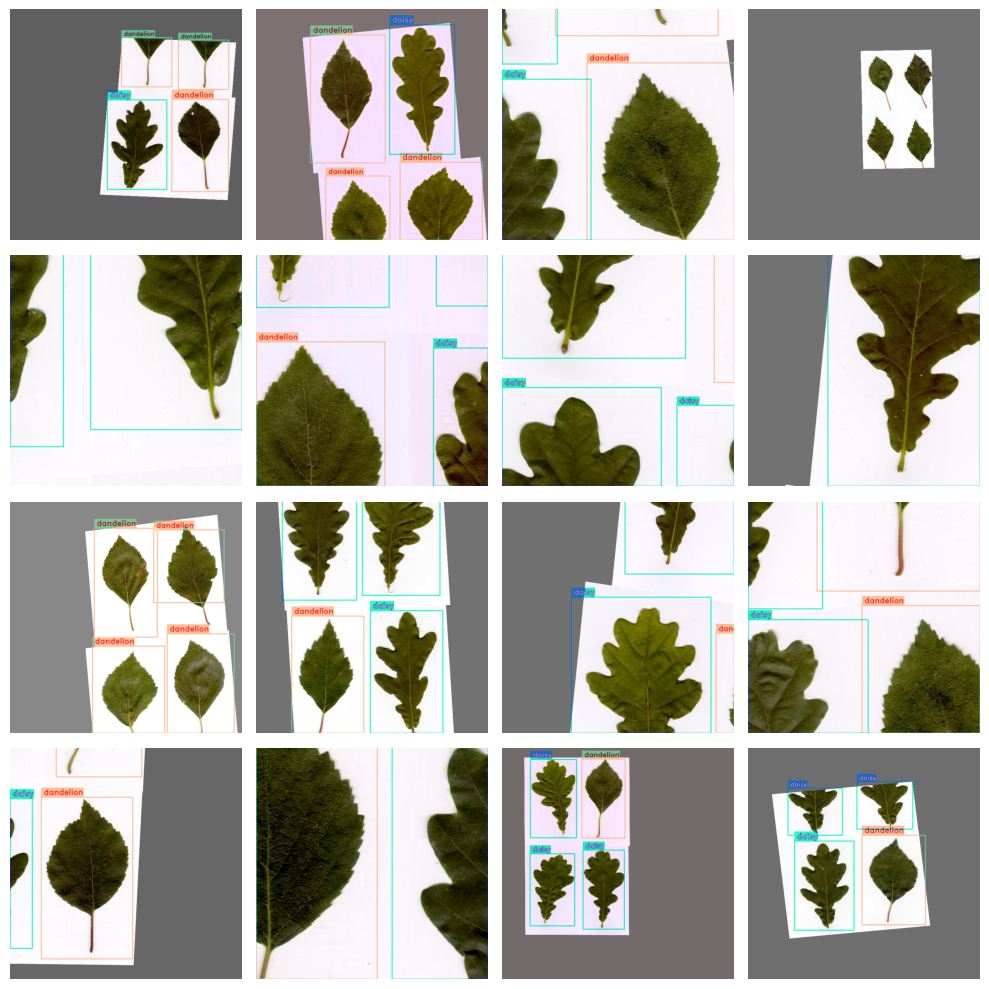

In [ ]:

train_data.dataset.plot(plot_transformed_data=True)

In [ ]:
train_params = {
    'silent_mode': False,
    "average_best_models":True,
    "warmup_mode": "linear_epoch_step",
    "warmup_initial_lr": 1e-6,
    "lr_warmup_epochs": 3,
    "initial_lr": 5e-4,
    "lr_mode": "cosine",
    "cosine_final_lr_ratio": 0.1,
    "optimizer": "Adam",
    "optimizer_params": {"weight_decay": 0.0001},
    "zero_weight_decay_on_bias_and_bn": True,
    "ema": True,
    "ema_params": {"decay": 0.9, "decay_type": "threshold"},
    "max_epochs": EPOCHS,
    "mixed_precision": True,
    "loss": PPYoloELoss(
        use_static_assigner=False,
        num_classes=len(dataset_params['classes']),
        reg_max=16
    ),
    "valid_metrics_list": [
        DetectionMetrics_050(
            score_thres=0.1,
            top_k_predictions=300,
            num_cls=len(dataset_params['classes']),
            normalize_targets=True,
            post_prediction_callback=PPYoloEPostPredictionCallback(
                score_threshold=0.01,
                nms_top_k=1000,
                max_predictions=300,
                nms_threshold=0.7
            )
        ),
        DetectionMetrics_050_095(
            score_thres=0.1,
            top_k_predictions=300,
            num_cls=len(dataset_params['classes']),
            normalize_targets=True,
            post_prediction_callback=PPYoloEPostPredictionCallback(
                score_threshold=0.01,
                nms_top_k=1000,
                max_predictions=300,
                nms_threshold=0.7
            )
        )
    ],
    "metric_to_watch": 'mAP@0.50:0.95'
}

In [ ]:
models_to_train = ['yolo_nas_s']

CHECKPOINT_DIR = 'checkpoints'

for model_to_train in models_to_train:
    trainer = Trainer(
        experiment_name=model_to_train,
        ckpt_root_dir=CHECKPOINT_DIR
    )

    model = models.get(
        model_to_train,
        num_classes=len(dataset_params['classes']),
        pretrained_weights="coco"
    )

    trainer.train(
        model=model,
        training_params=train_params,
        train_loader=train_data,
        valid_loader=val_data
    )

[2024-06-05 19:40:54] WARNING - checkpoint_utils.py - :warning: The pre-trained models provided by SuperGradients may have their own licenses or terms and conditions derived from the dataset used for pre-training.
 It is your responsibility to determine whether you have permission to use the models for your use case.
 The model you have requested was pre-trained on the coco dataset, published under the following terms: https://cocodataset.org/#termsofuse
[2024-06-05 19:40:54] INFO - checkpoint_utils.py - License Notification: YOLO-NAS pre-trained weights are subjected to the specific license terms and conditions detailed in 
https://github.com/Deci-AI/super-gradients/blob/master/LICENSE.YOLONAS.md
By downloading the pre-trained weight files you agree to comply with these terms.
Downloading: "https://sghub.deci.ai/models/yolo_nas_s_coco.pth" to /root/.cache/torch/hub/checkpoints/yolo_nas_s_coco.pth
100%|██████████| 73.1M/73.1M [00:06<00:00, 12.8MB/s]
[2024-06-05 19:41:01] INFO - checkpo

The console stream is now moved to checkpoints/yolo_nas_s/RUN_20240605_194102_061208/console_Jun05_19_41_02.txt


[2024-06-05 19:41:11] INFO - sg_trainer_utils.py - TRAINING PARAMETERS:
    - Mode:                         Single GPU
    - Number of GPUs:               1          (1 available on the machine)
    - Full dataset size:            90         (len(train_set))
    - Batch size per GPU:           16         (batch_size)
    - Batch Accumulate:             1          (batch_accumulate)
    - Total batch size:             16         (num_gpus * batch_size)
    - Effective Batch size:         16         (num_gpus * batch_size * batch_accumulate)
    - Iterations per epoch:         5          (len(train_loader))
    - Gradient updates per epoch:   5          (len(train_loader) / batch_accumulate)
    - Model: YoloNAS_S  (19.02M parameters, 19.02M optimized)
    - Learning Rates and Weight Decays:
      - default: (19.02M parameters). LR: 0.0005 (19.02M parameters) WD: 0.0, (42.14K parameters), WD: 0.0001, (18.98M parameters)

[2024-06-05 19:41:11] INFO - sg_trainer.py - Started training for 5

SUMMARY OF EPOCH 0
├── Train
│   ├── Ppyoloeloss/loss_cls = 2.0647
│   ├── Ppyoloeloss/loss_iou = 0.6471
│   ├── Ppyoloeloss/loss_dfl = 0.7755
│   └── Ppyoloeloss/loss = 3.4873
└── Validation
    ├── Ppyoloeloss/loss_cls = 3.0018
    ├── Ppyoloeloss/loss_iou = 0.2661
    ├── Ppyoloeloss/loss_dfl = 0.5119
    ├── Ppyoloeloss/loss = 3.7798
    ├── Precision@0.50 = 0.0
    ├── Recall@0.50 = 0.0
    ├── Map@0.50 = 0.1641
    ├── F1@0.50 = 0.0
    ├── Best_score_threshold = 0.04
    ├── Precision@0.50:0.95 = 0.0
    ├── Recall@0.50:0.95 = 0.0
    ├── Map@0.50:0.95 = 0.0503
    └── F1@0.50:0.95 = 0.0



Validating epoch 1: 100%|██████████| 2/2 [00:03<00:00,  1.58s/it]
[2024-06-05 19:41:38] INFO - base_sg_logger.py - Checkpoint saved in checkpoints/yolo_nas_s/RUN_20240605_194102_061208/ckpt_best.pth
[2024-06-05 19:41:38] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.1960192173719406


...

Validating epoch 48: 100%|██████████| 2/2 [00:03<00:00,  1.74s/it]


SUMMARY OF EPOCH 48
├── Train
│   ├── Ppyoloeloss/loss_cls = 0.652
│   │   ├── Epoch N-1      = 0.6253 (↗ 0.0268)
│   │   └── Best until now = 0.6139 (↗ 0.0381)
│   ├── Ppyoloeloss/loss_iou = 0.2954
│   │   ├── Epoch N-1      = 0.2911 (↗ 0.0042)
│   │   └── Best until now = 0.2888 (↗ 0.0065)
│   ├── Ppyoloeloss/loss_dfl = 0.4602
│   │   ├── Epoch N-1      = 0.4597 (↗ 0.0005)
│   │   └── Best until now = 0.445  (↗ 0.0152)
│   └── Ppyoloeloss/loss = 1.4076
│       ├── Epoch N-1      = 1.3761 (↗ 0.0315)
│       └── Best until now = 1.351  (↗ 0.0566)
└── Validation
    ├── Ppyoloeloss/loss_cls = 0.5869
    │   ├── Epoch N-1      = 0.5881 (↘ -0.0012)
    │   └── Best until now = 0.5644 (↗ 0.0224)
    ├── Ppyoloeloss/loss_iou = 0.4935
    │   ├── Epoch N-1      = 0.4965 (↘ -0.0029)
    │   └── Best until now = 0.2306 (↗ 0.2629)
    ├── Ppyoloeloss/loss_dfl = 0.7198
    │   ├── Epoch N-1      = 0.7219 (↘ -0.0021)
    │   └── Best until now = 0.5044 (↗ 0.2154)
    ├── Ppyoloeloss/loss = 1.8002

Validating epoch 49: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


SUMMARY OF EPOCH 49
├── Train
│   ├── Ppyoloeloss/loss_cls = 0.6138
│   │   ├── Epoch N-1      = 0.652  (↘ -0.0382)
│   │   └── Best until now = 0.6139 (↘ -0.0002)
│   ├── Ppyoloeloss/loss_iou = 0.297
│   │   ├── Epoch N-1      = 0.2954 (↗ 0.0016)
│   │   └── Best until now = 0.2888 (↗ 0.0082)
│   ├── Ppyoloeloss/loss_dfl = 0.4663
│   │   ├── Epoch N-1      = 0.4602 (↗ 0.0062)
│   │   └── Best until now = 0.445  (↗ 0.0213)
│   └── Ppyoloeloss/loss = 1.3772
│       ├── Epoch N-1      = 1.4076 (↘ -0.0304)
│       └── Best until now = 1.351  (↗ 0.0261)
└── Validation
    ├── Ppyoloeloss/loss_cls = 0.5858
    │   ├── Epoch N-1      = 0.5869 (↘ -0.0011)
    │   └── Best until now = 0.5644 (↗ 0.0214)
    ├── Ppyoloeloss/loss_iou = 0.4887
    │   ├── Epoch N-1      = 0.4935 (↘ -0.0048)
    │   └── Best until now = 0.2306 (↗ 0.2581)
    ├── Ppyoloeloss/loss_dfl = 0.713
    │   ├── Epoch N-1      = 0.7198 (↘ -0.0068)
    │   └── Best until now = 0.5044 (↗ 0.2086)
    ├── Ppyoloeloss/loss = 1.78

[2024-06-05 20:00:17] INFO - sg_trainer.py - RUNNING ADDITIONAL TEST ON THE AVERAGED MODEL...
Validating epoch 50: 100%|██████████| 2/2 [00:01<00:00,  1.19it/s]